# Importing XDF files in HyPyP
@Author : [@jonasmago](https://github.com/jonasmago) & [@FranckPrts](https://github.com/FranckPrts).

Updated by : Patrice Fortin

Last updated: 

This tutorial guides you in using the `XDFImport` class provided by [hypyp.io.py](https://github.com/ppsp-team/HyPyP/blob/master/hypyp/xdf/).

[XDF files](https://github.com/sccn/xdf) are generally produced by [LSL](https://labstreaminglayer.readthedocs.io/index.html) when recording multi-stream time-series data generated in different modalities (e.g., EEG, video, audio). This open-source format enables associating extensive meta information. It is tailored for biosignal data (e.g., EEG, EOG, ECG, MEG) but still supports high sampling rate data (e.g., audio) or high-channel data (e.g., video, fMRI).

In this tutorial, we convert 2 EEG streams from a sample XDF into 2 `mne.Raw`.


## Imports & path to XDF file

In [1]:
from hypyp.xdf import XDFImport

path_xdf = "../data/dyad-example-noise.xdf"

## The `XDF_IMPORT` class

The class has the following arguments:


> > > TO UPDATE



- `path` : (str) Path to LSL data (i.e., XDF file). Can be absolute or relative. 
- `type` : (str) Define which type of stream the user is looking for. When converting EEG streams, or using  `convert_all_eeg=True`, the type must be set to "EEG". By default, `"EEG"`.
- `stream_idx` : (list) List of the stream index(es) in the XDF the user whish to import (must be of type "EEG"). By default, `None`. When set to `None`, `stream_idx` is appended the index of all streams of type `"EEG"`.
- `sfreq` : (float) Sampling frequency, can either be set automatically by the class or given by the user.
- `print_stream_name` : (boolean) Wheather the class should print the stream and their respective index in the XDF. By default, `True`.
- `convert_all_eeg` : (boolean) Defines if the class must automatically look for stream(s) of `type="EEG"` and convert them. By default, `True`.
- `save_FIF_path` (string) By default `None`. If set to a path, the class will save the targeted EEG stream as .fif file at that location (e.g., `"./figures/"` or `"~/Documents/current_project/"`). It will also create the folder structure if needed.
- `eeg_montage` (string) montage to apply to the eeg object that are converted. (all montages availables with mne can be found by running `mne.channels.get_builtin_montages()`)



First, we instanciat the class naively with the following argument to take a look at our XDF content: 
```
print_stream_name   = True
convert_all_eeg     = False
```

*We leave `sfreq` and `type` to their respective defaults so the class respectively determines the sampling rate and search for the EEG streams and their respective informations.*

In [2]:
xdf = XDFImport(path_xdf, convert_to_mne=False)
xdf.print_available_streams()

List of available streams in XDF file ../data/dyad-example-noise.xdf:
  Stream id 3 of type 'Markers' with name 'LSLOutletHS1-Markers'
    Channel names: Markers_001
    Channel types: stim
  Stream id 1 of type 'Accelerometer' with name 'LSLOutletHS1-Accelerometer'
    Channel names: X,Y,Z
    Channel types: misc,misc,misc
  Stream id 8 of type 'Quality' with name 'LSLOutletHS1-Quality'
    Channel names: Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch7,Ch8,Ch9,Ch10,Ch11,Ch12,Ch13,Ch14,Ch15,Ch16,Ch17,Ch18,Ch19,Ch20,Ch21,Ch22,Ch23,Ch24,Ch25,Ch26,Ch27,Ch28,Ch29,Ch30,Ch31,Ch32
    Channel types: quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality,quality
  Stream id 2 of type 'EEG' with name 'LSLOutletHS1-EEG'
    Channel names: Ch1,Ch2,Ch3,Ch4,Ch5,Ch6,Ch7,Ch8,Ch9,Ch10,Ch11,Ch12,Ch13,Ch14,Ch15,Ch16,Ch17,Ch18,Ch19,Ch

**Great!** Now we know what our XDF is conposed of. Let's explore different ways of converting on or multiple EEG stream from it into `mne.Raw` object(s).

### Two ways to use `IMPORT_XDF`


Here we look into two examples where we use `IMPORT_XDF` to convert the EEG streams into `mne.Raw`(s):
- **Situation 1:** The user wants to (blindly) **convert all** available EEG stream(s) in the XDF into `mne.Raw`(s)
- **Situation 2:** The user knows the index and/or name of one/multiple EEG stream(s) to convert

#### Situation 1
The user wants to (blindly) **convert all** available EEG stream(s) in the XDF into `mne.Raw`(s).

In [3]:
xdf = XDFImport(path_xdf)

Creating RawArray with float64 data, n_channels=32, n_times=5003
    Range : 0 ... 5002 =      0.000 ...    10.004 secs
Ready.
Creating RawArray with float64 data, n_channels=32, n_times=5004
    Range : 0 ... 5003 =      0.000 ...    10.006 secs
Ready.


In [4]:
xdf.raw_all

{'LSLOutletHS1-EEG': <RawArray | 32 x 5003 (10.0 s), ~1.3 MB, data loaded>,
 'LSLOutletHS2-EEG': <RawArray | 32 x 5004 (10.0 s), ~1.3 MB, data loaded>}

#### Situation 2
The user knows the indexes of the **multiple** EEG streams they want to convert. Here using both the chanel indexes and names.

In [5]:
# eeg = XDF_IMPORT(path_xdf, stream_idx= ["AAB044_EEG", 8], print_stream_name=False, convert_all_eeg=False, scale='auto', save_FIF_path=None)
xdf = XDFImport(path_xdf, stream_matches=["LSLOutletHS1-EEG", 7], scale=10e-8)

Creating RawArray with float64 data, n_channels=32, n_times=5003
    Range : 0 ... 5002 =      0.000 ...    10.004 secs
Ready.
Creating RawArray with float64 data, n_channels=32, n_times=5004
    Range : 0 ... 5003 =      0.000 ...    10.006 secs
Ready.


In [6]:
xdf.raw_all

{'LSLOutletHS1-EEG': <RawArray | 32 x 5003 (10.0 s), ~1.3 MB, data loaded>,
 'LSLOutletHS2-EEG': <RawArray | 32 x 5004 (10.0 s), ~1.3 MB, data loaded>}

# Extracting the XDF_IMPORT's output(s)

A practical way to save the converted stream to mne.Raw is to set a path for the class `XDF_IMPORT` to save the .fif file of each stream

You can now find the `Raw` that were converted in the dictionary `eeg.raw_all`:

In [7]:
xdf.raw_all

{'LSLOutletHS1-EEG': <RawArray | 32 x 5003 (10.0 s), ~1.3 MB, data loaded>,
 'LSLOutletHS2-EEG': <RawArray | 32 x 5004 (10.0 s), ~1.3 MB, data loaded>}

To extract one of the `mne.Raw` object form the `eeg` class, you can do the following:

In [8]:
standalone_raw = xdf.raw_all["LSLOutletHS1-EEG"]
standalone_raw

Measurement date,Unknown
Experimenter,Unknown
Participant,LSLOutletHS1-EEG
Digitized points,Not available
Good channels,32 EEG
Bad channels,None
EOG channels,Not available
ECG channels,Not available
Sampling frequency,500.00 Hz
Highpass,0.00 Hz
Lowpass,250.00 Hz


The name of the original XDF stream name is also stored in the `subject_info` dictionary nested in `Raw.Info`. So even if you separate a `Raw` from its key, you can still find the stream name's in its info.

In [9]:
# Print the name of the stream from the Raw.info object itself
print(f"standalone_raw subject info: {standalone_raw.info['subject_info']['his_id']}")

standalone_raw subject info: LSLOutletHS1-EEG


Once extracted, you can perform any analysis to the `standalone_raw` as you would with a `mne.Raw`!

Using matplotlib as 2D backend.


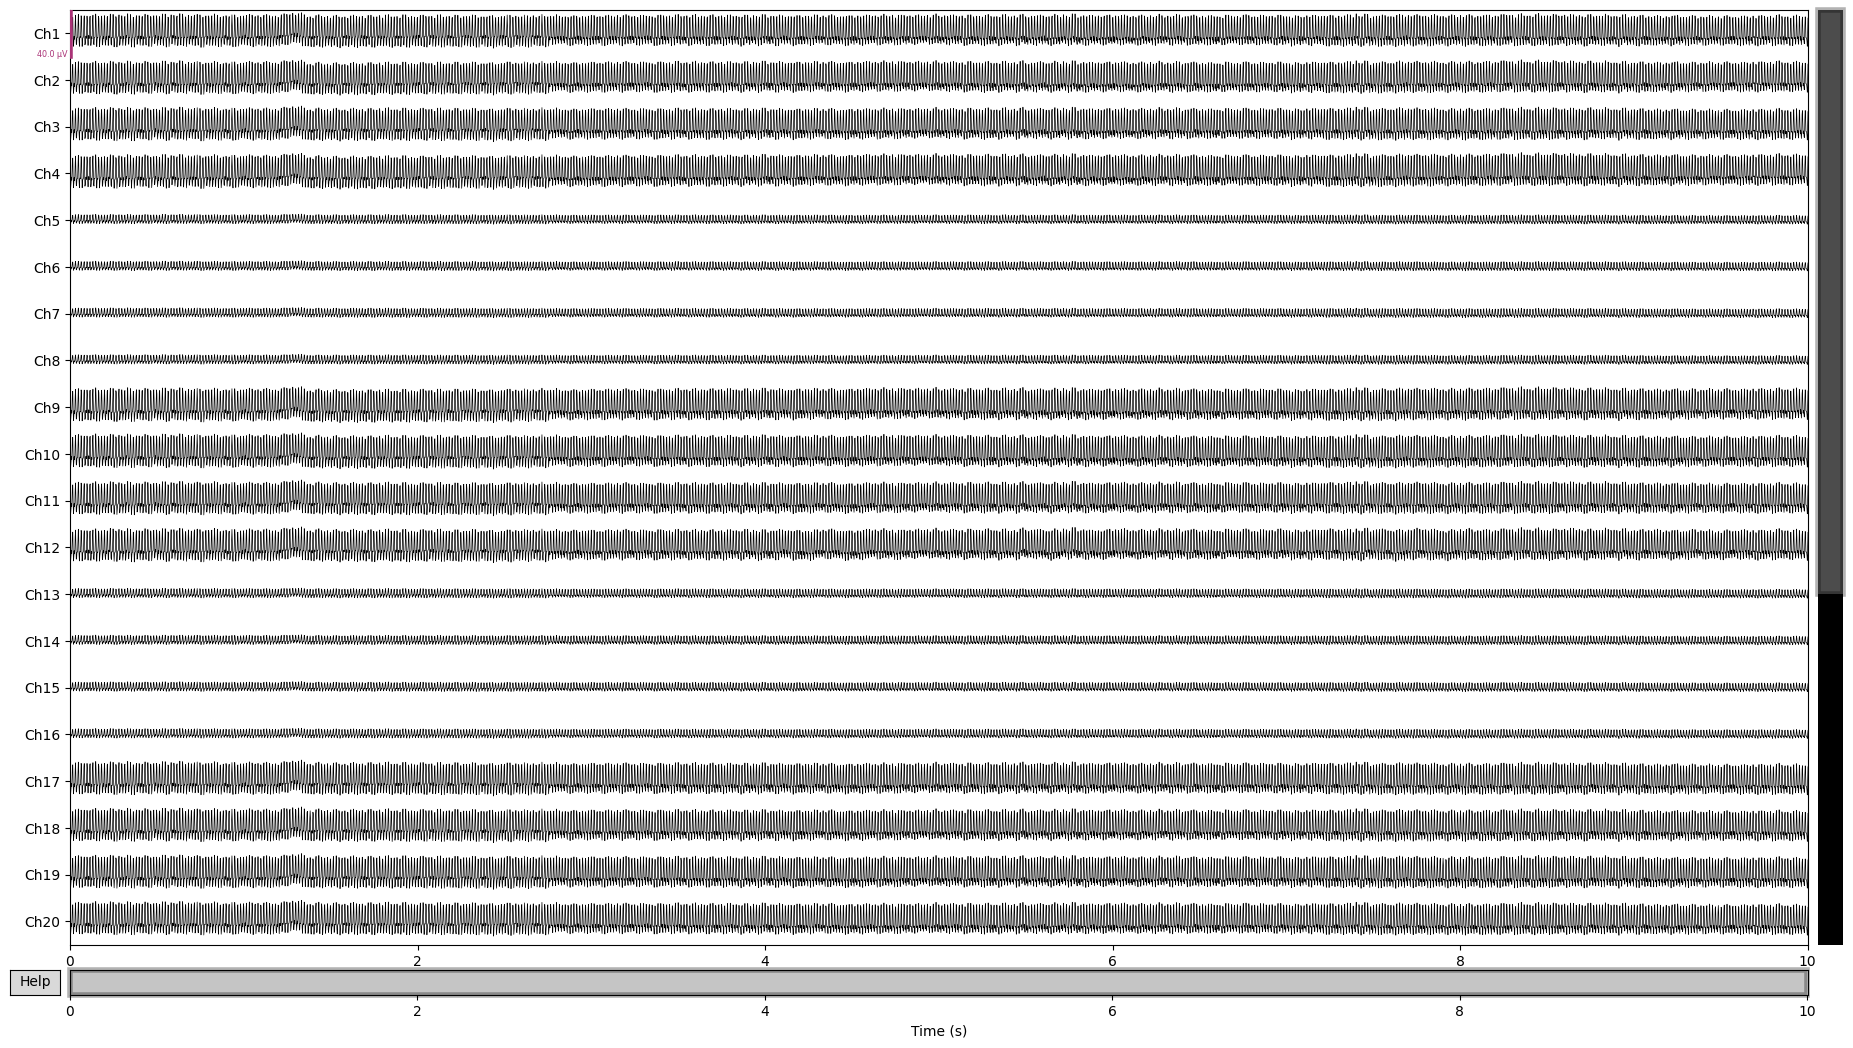

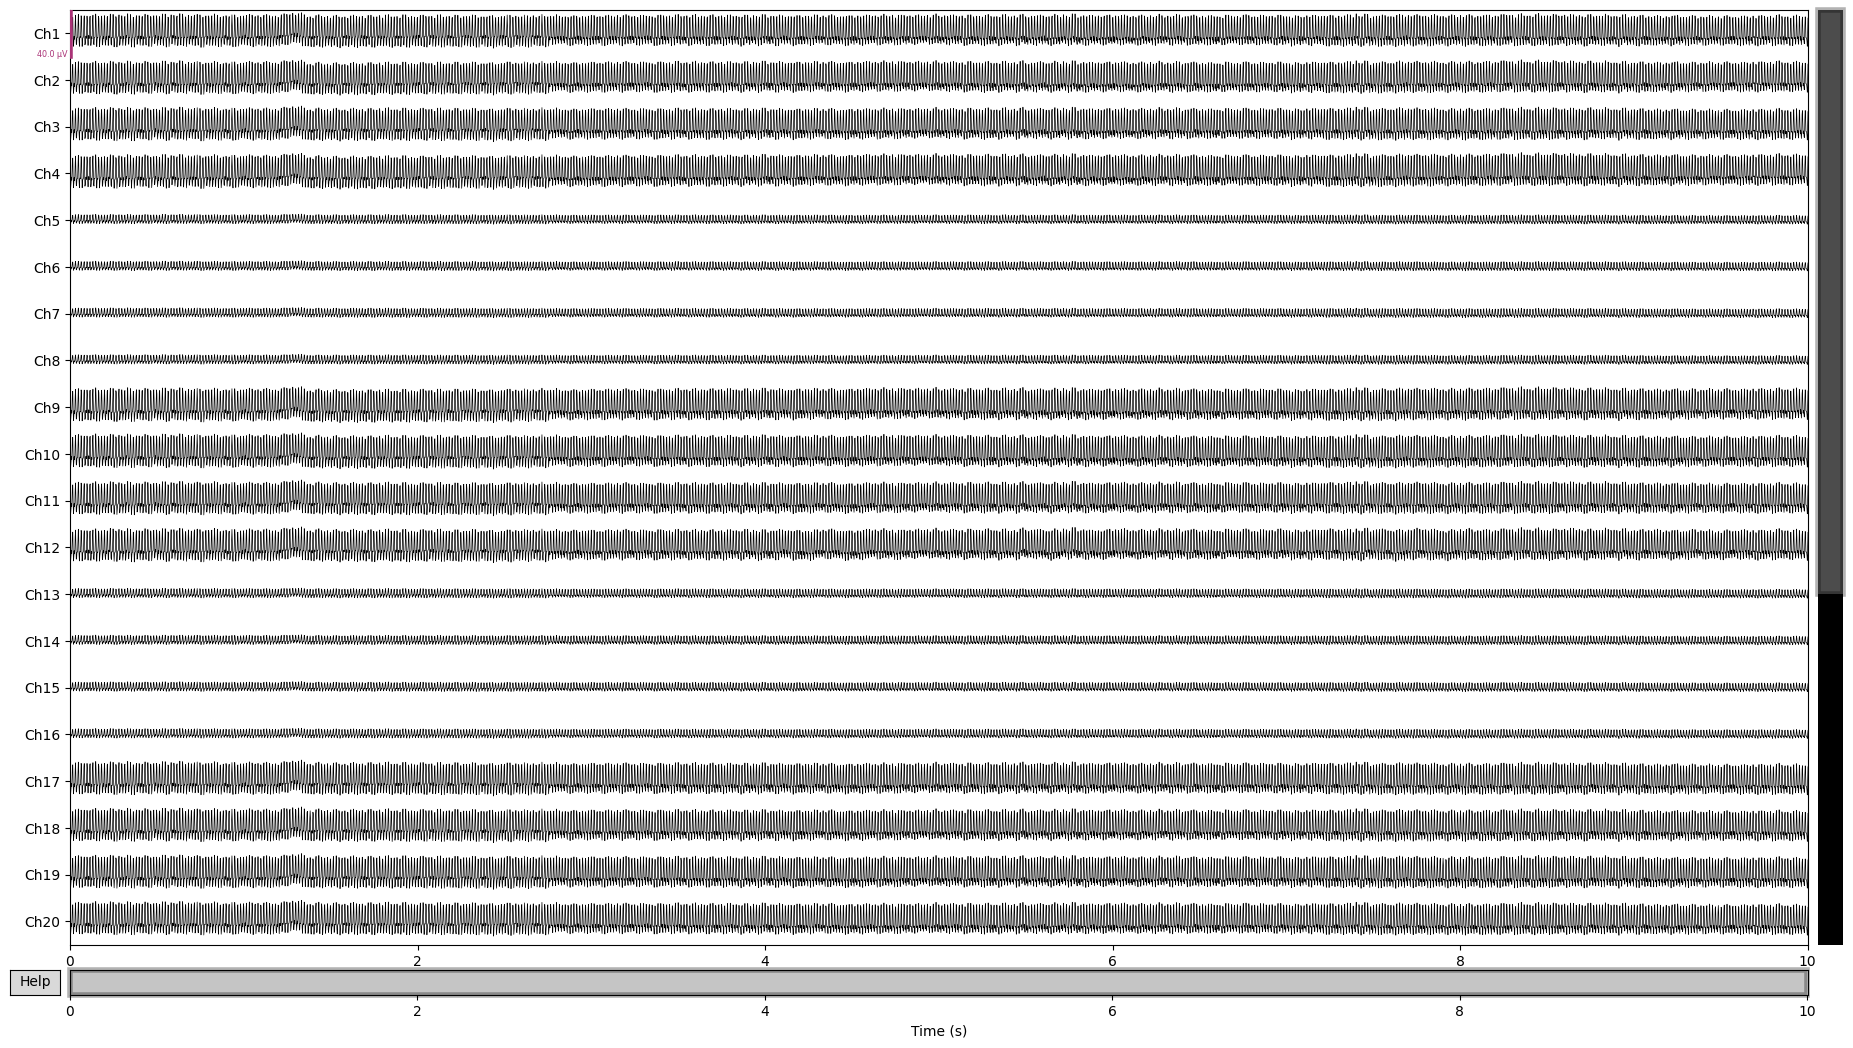

In [10]:
standalone_raw.plot()

## Montage

**Careful!** 

`XDF_IMPORT` does not set the montage automatically! Now that we have converted our stream(s) to `mne.Raw` object(s), we can fix that by setting the montage following [mne's general instruction for setting montage](https://mne.tools/stable/auto_tutorials/intro/40_sensor_locations.html#about-montages-and-layouts). For example:

Setting 'standard_1020' as the montage for streams: LSLOutletHS1-EEG,LSLOutletHS2-EEG


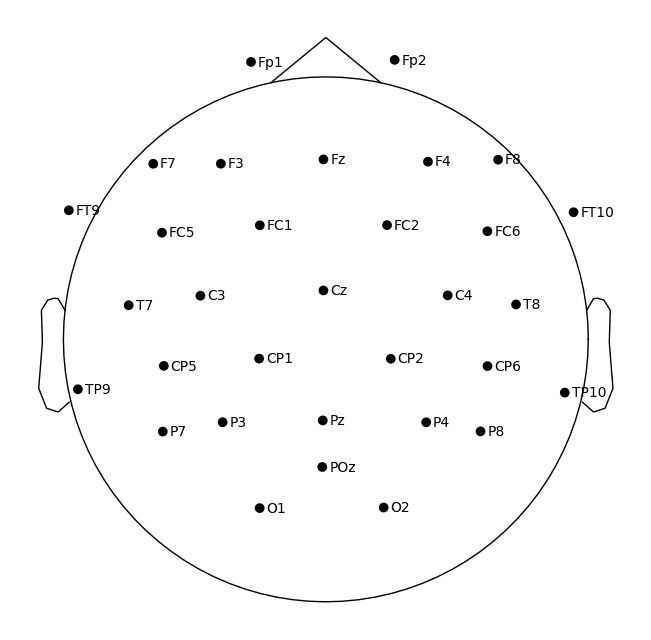

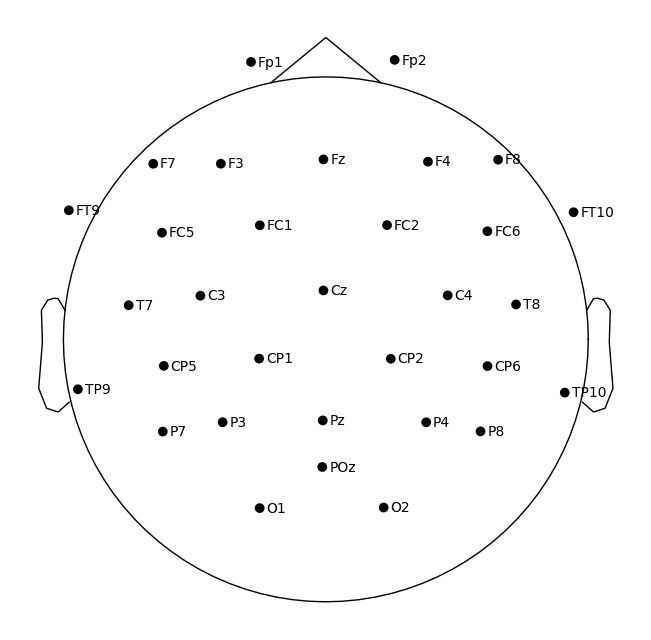

In [11]:
# Set the montage to the standard 10-20 montage
xdf.rename_channels(['Fp1', 'Fp2', 'F3', 'F4', 'C3', 'C4', 'P3', 'P4', 'O1', 'O2', 'F7', 'F8', 'T7', 'T8', 'P7', 'P8', 'Fz', 'Cz', 'Pz', 'POz', 'FC1', 'FC2', 'CP1', 'CP2', 'FC5', 'FC6', 'CP5', 'CP6', 'FT9', 'FT10', 'TP9', 'TP10'])
xdf.set_montage('standard_1020')

# Plot the sensors
xdf.raw_all['LSLOutletHS1-EEG'].plot_sensors(show_names=True)

### Using sample XDF data from MNE


Creating RawArray with float64 data, n_channels=5, n_times=2320128
    Range : 0 ... 2320127 =      0.000 ...   232.013 secs
Ready.
List of available streams in XDF file /home/patrice/mne_data/MNE-misc-data/xdf/sub-P001_ses-S004_task-Default_run-001_eeg_a2.xdf:
  Stream id 1 of type 'EEG' with name 'actiCHamp-16080699'
    Channel names: Left-,Left+,Right-,Right+,Markers
    Channel types: eeg,eeg,eeg,eeg,stim
['Left-', 'Left+', 'Right-', 'Right+', 'Markers']


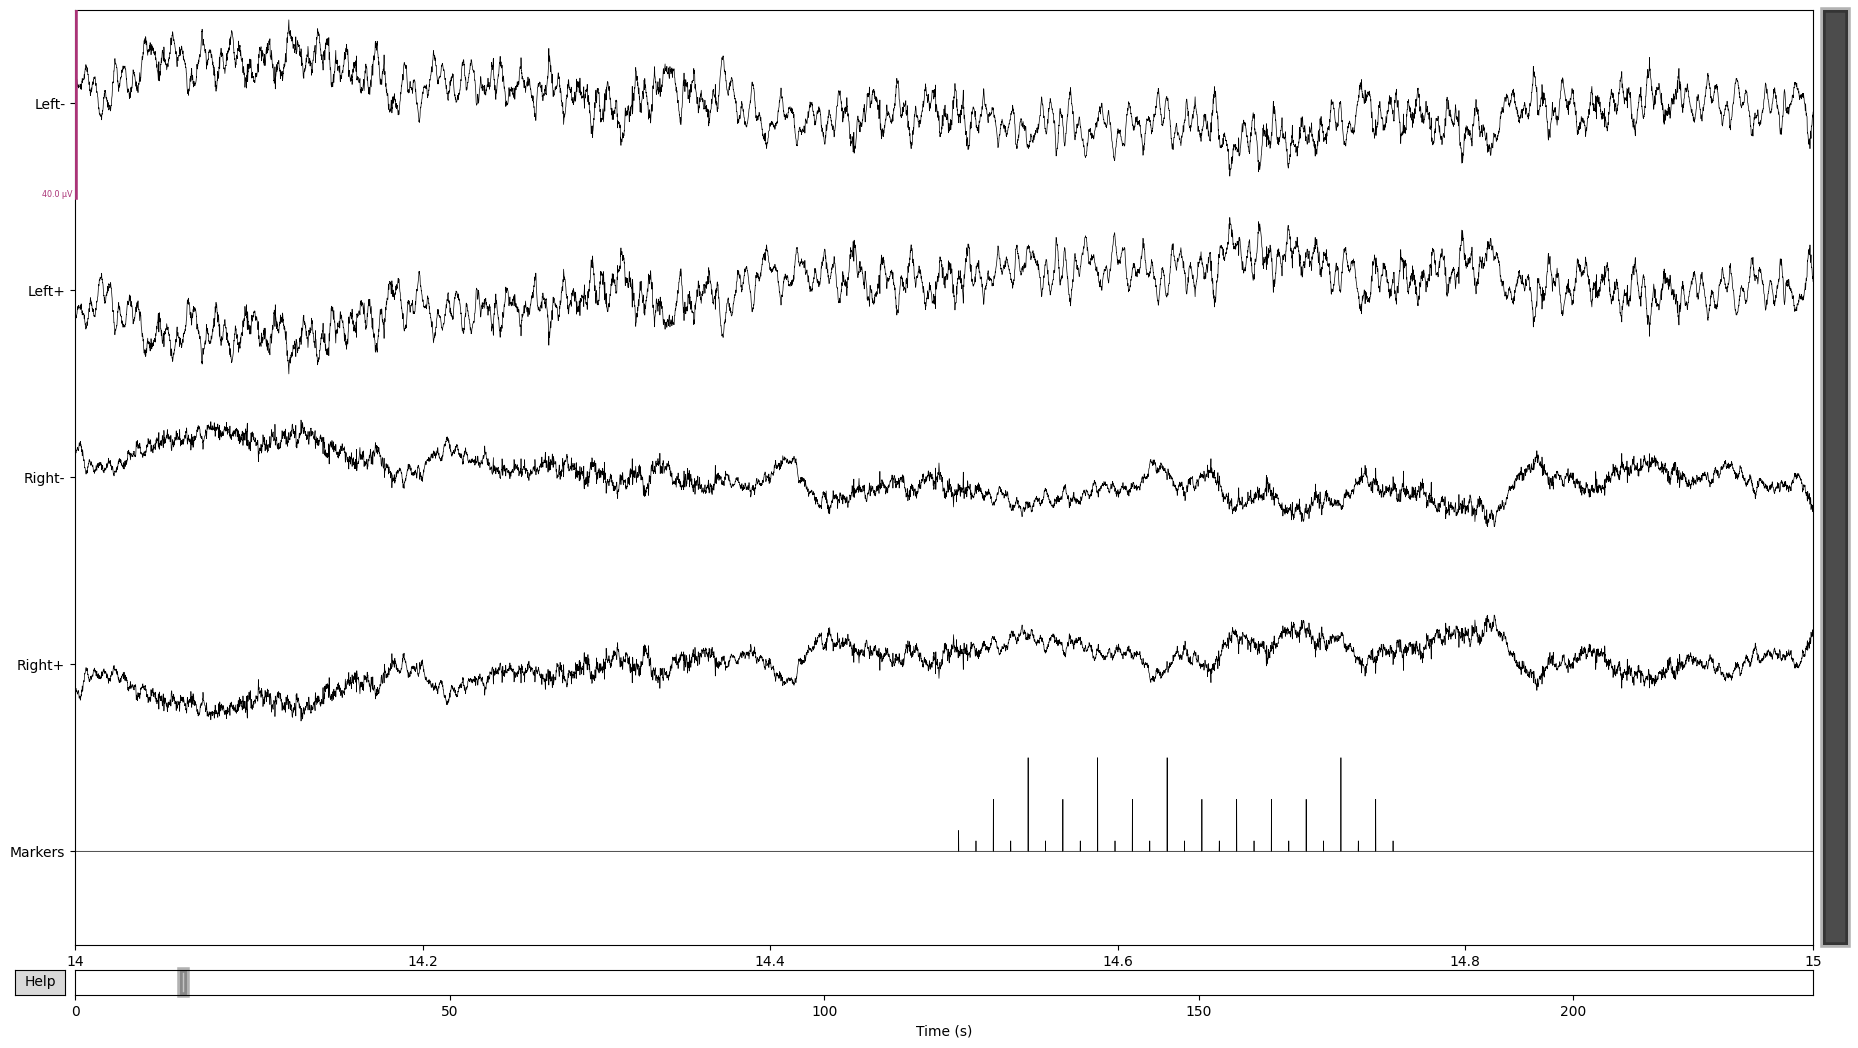

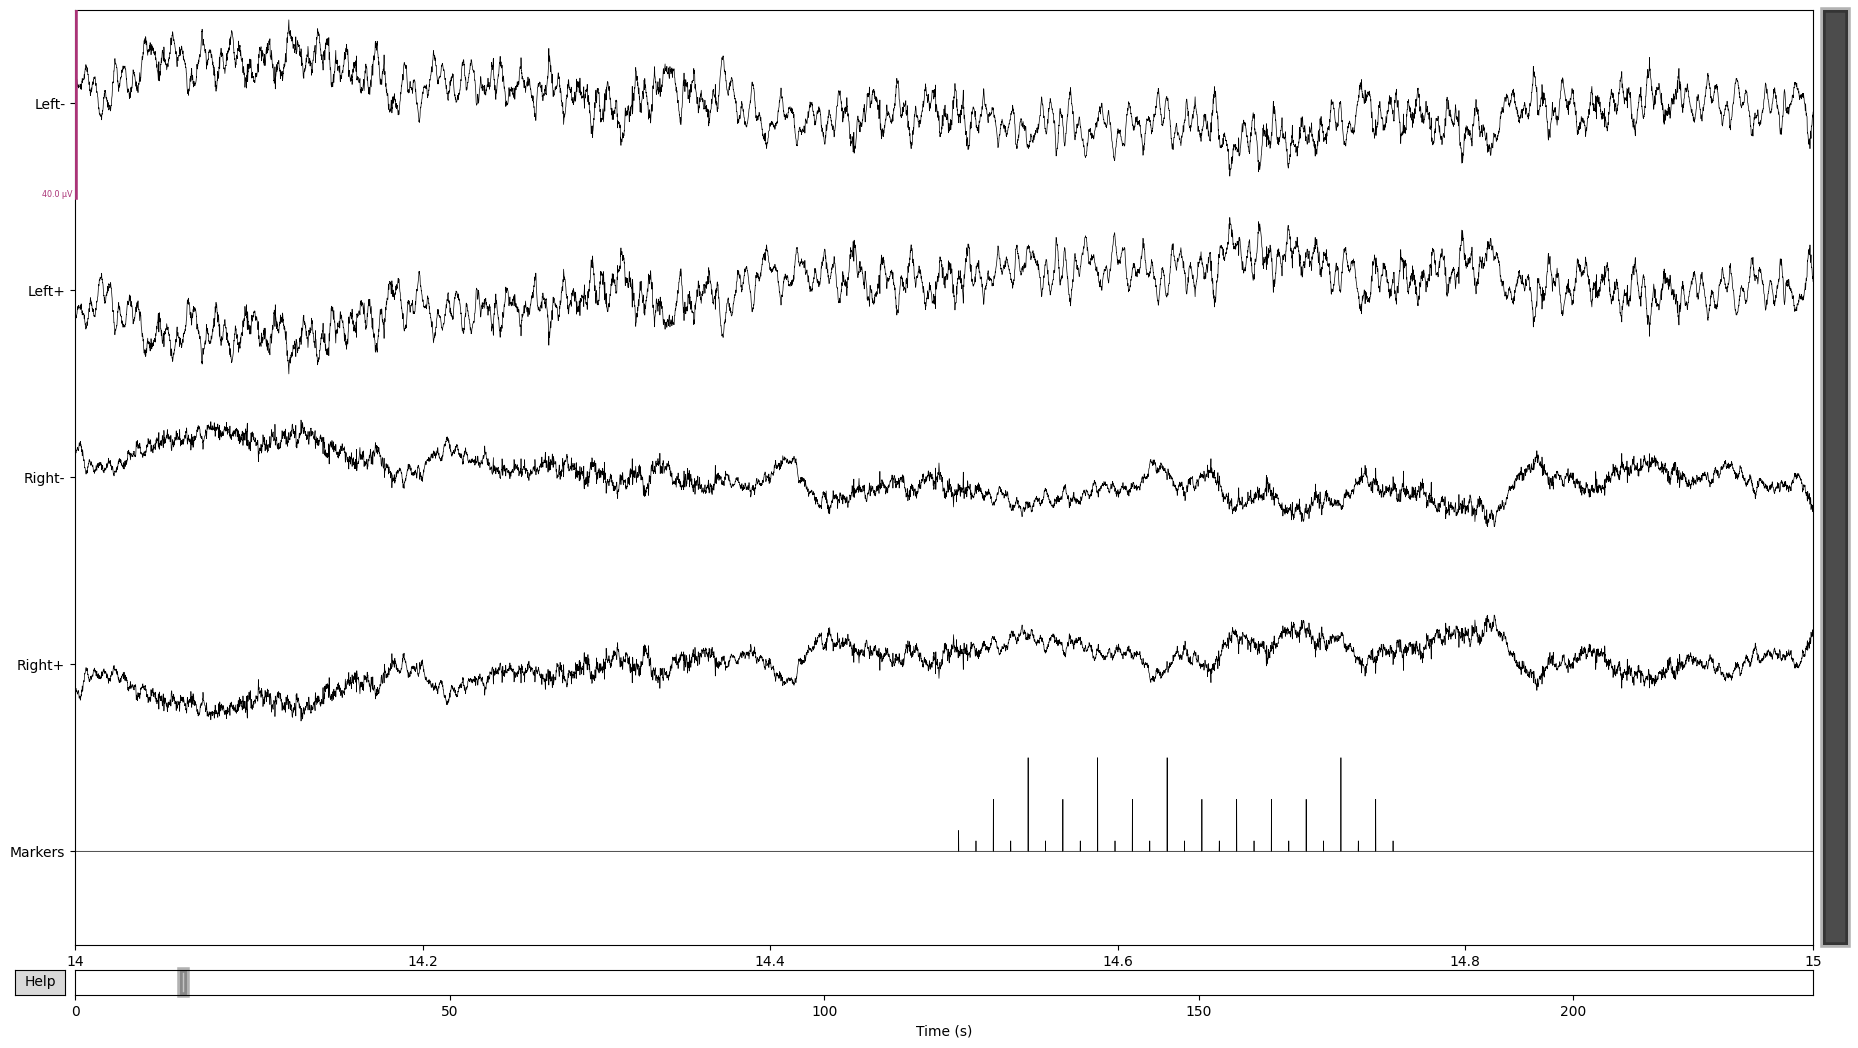

In [ ]:
# See https://mne.tools/stable/auto_examples/io/read_xdf.html
from mne.datasets import misc

file_path = misc.data_path() / "xdf" / "sub-P001_ses-S004_task-Default_run-001_eeg_a2.xdf"

xdf = XDFImport(file_path, scale=10e-9)

xdf.print_available_streams()
print(xdf.selected_streams[0].ch_names)

xdf.raw_all[xdf.selected_stream_names[0]].plot(duration=1, start=14)